# FAERS DDI Corrections Notebook

**Purpose:** Address five open issues in the temporal stability analysis and DrugBank validation from the main thesis notebook (`FDA_FAERS_JoshBuck.ipynb`, Cells 70-82).

**This notebook supersedes Cells 70-82 of FDA_FAERS_JoshBuck.ipynb.** Those cells remain for audit trail purposes. All corrected outputs (CSVs, figures) are saved with the same filenames to replace stale versions.

**Issues addressed:**
1. **FDR Consistency** - Temporal signal definition now matches main pipeline (ROR > 2.0 AND CI > 1.0 AND P_VALUE_FDR < 0.05)
2. **Confounding finding** - Recalculate stable vs unstable characteristics after FDR fix
3. **DrugBank validation AUC = 0.51** - Replication with "complementary evidence" framing
4. **Figure 4 null result** - Same-class vs cross-class ROR with Mann-Whitney U test
5. **Stale figure outputs** - Noted for re-run of `FDA_Figures.ipynb`

**Data dependencies (all CSVs, no kernel state from main notebook):**
- `FAERS_DDI_ROR_ALL.csv` (226,085 rows)
- `FAERS_TEMPORAL_STABILITY.csv` (70,901 rows)
- `FAERS_DDI_SIGNALS_HIGH_CONFIDENCE.csv` (5,472 rows)
- `DRUGBANK_DDI_REFERENCE.csv` (1.45M rows)
- `drug_atc_mapping.csv` (684 rows)

In [1]:
# ============================================================
# IMPORTS AND DATA LOADING
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, norm, pearsonr, spearmanr
from sklearn.metrics import roc_curve, auc

# Matplotlib defaults
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11

print("=" * 60)
print("LOADING DATA")
print("=" * 60)

# Load all CSVs
ror_all = pd.read_csv("../data/signals/FAERS_DDI_ROR_ALL.csv")
print(f"ROR ALL: {len(ror_all):,} rows")

temporal = pd.read_csv("../results/FAERS_TEMPORAL_STABILITY.csv")
print(f"Temporal stability: {len(temporal):,} rows")

hc = pd.read_csv("../data/signals/FAERS_DDI_SIGNALS_HIGH_CONFIDENCE.csv")
print(f"High-confidence signals: {len(hc):,} rows")

db_ref = pd.read_csv("../data/raw/DRUGBANK_DDI_REFERENCE.csv")
print(f"DrugBank reference: {len(db_ref):,} rows")

atc = pd.read_csv("../data/raw/drug_atc_mapping.csv")
print(f"ATC mapping: {len(atc):,} rows")

# Split PAIR into DRUG_A and DRUG_B
for df in [ror_all, hc]:
    split = df['PAIR'].str.split(r'\s*\+\s*', n=1, expand=True)
    df['DRUG_A'] = split[0]
    df['DRUG_B'] = split[1]

# ATC lookup
atc_lookup = dict(zip(atc['DRUG'], atc['RISK_CLASS']))
atc_l1_lookup = dict(zip(atc['DRUG'], atc['ATC_L1_NAME']))

# Map classes onto high-confidence signals
hc['CLASS_A'] = hc['DRUG_A'].map(atc_lookup).fillna('Unclassified')
hc['CLASS_B'] = hc['DRUG_B'].map(atc_lookup).fillna('Unclassified')

# Compute PCT_SERIOUS for ror_all
ror_all['PCT_SERIOUS'] = (ror_all['A_SERIOUS_EXPOSED'] / ror_all['N_EXPOSED'] * 100)

print("\n" + "=" * 60)
print("DATA LOADED SUCCESSFULLY")
print("=" * 60)

LOADING DATA
ROR ALL: 226,085 rows
Temporal stability: 70,901 rows
High-confidence signals: 5,472 rows
DrugBank reference: 1,455,276 rows
ATC mapping: 682 rows

DATA LOADED SUCCESSFULLY


## Load FDR-corrected temporal data

This notebook depends on `temporal_corrected` (the FDR-corrected 27,881 main-pipeline signals produced by `07_corrections_fdr_fix.ipynb`). Load it from the saved CSV so this notebook can run standalone.

In [2]:
# Load temporal_corrected from the CSV saved by 07_corrections_fdr_fix.ipynb
temporal_corrected = pd.read_csv("../results/FAERS_TEMPORAL_STABILITY_CORRECTED.csv")
print(f"Loaded temporal_corrected: {len(temporal_corrected):,} rows")

Loaded temporal_corrected: 27,881 rows


## 4. Same-Class vs Cross-Class DDI Signal Strength (Figure 4)

**Problem:** Figure 4 shows a null result -- same-class and cross-class DDI signals have identical median ROR (2.80 vs 2.80, p = 0.64). The previous version was missing formal statistical tests.

**Fix:** Add Mann-Whitney U tests for ROR, N_EXPOSED, and PCT_SERIOUS distributions. Frame the null result: DDI risk is driven by specific drug-level mechanisms (CYP inhibition, QT prolongation), not broad pharmacological class membership.

SAME-CLASS VS CROSS-CLASS DDI SIGNAL STRENGTH

Same-Class vs Cross-Class Summary:
                  count  mean_ror  median_ror  mean_n  mean_serious_pct
interaction_type                                                       
Cross-class        4599      3.28         2.8  217.90             75.44
Same-class          750      3.25         2.8  242.69             75.35

Mann-Whitney U Tests:
  ROR:          U = 1,706,220, p = 0.6388, r = 0.011
  N_EXPOSED:    U = 1,900,172, p = 0.0000
  PCT_SERIOUS:  U = 1,706,096, p = 0.6366


/var/folders/5j/6ll410dd2p50x_mj8rswpbdw0000gn/T/ipykernel_86804/3470061596.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([cross_ror, same_ror], labels=['Cross-class', 'Same-class'],
/var/folders/5j/6ll410dd2p50x_mj8rswpbdw0000gn/T/ipykernel_86804/3470061596.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[2].boxplot([cross_pct, same_pct], labels=['Cross-class', 'Same-class'],


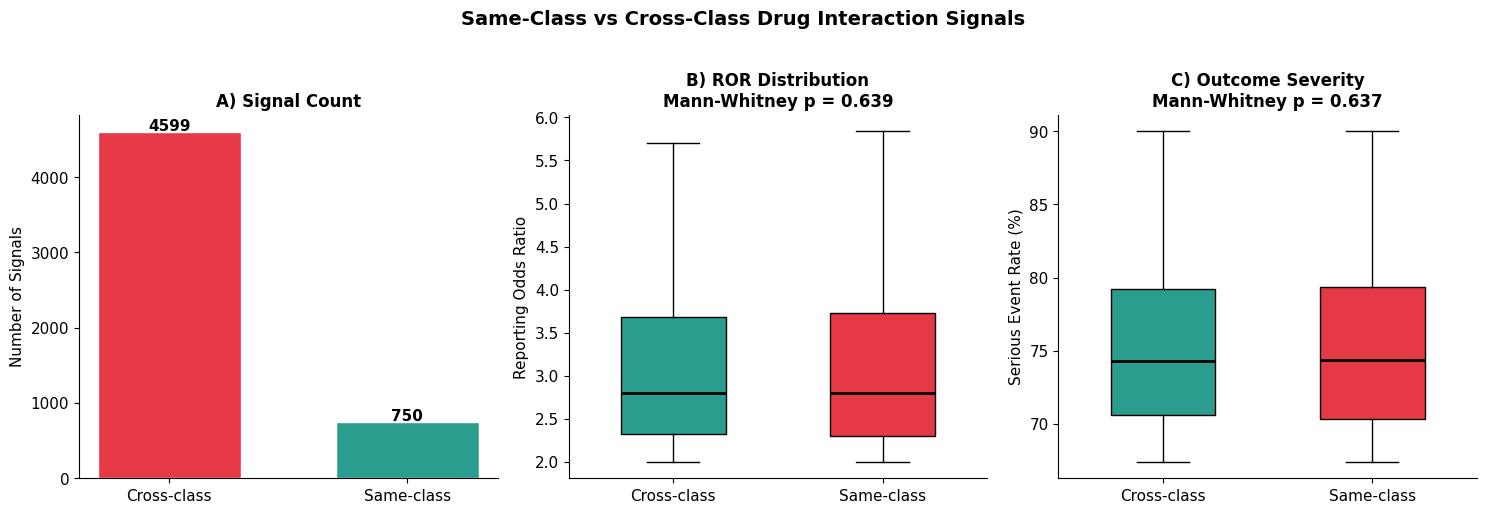


Saved: fig4_same_vs_cross_class.png


In [3]:
# ============================================================
# FIGURE 4: Same-Class vs Cross-Class Polypharmacy Risk
# ============================================================
print("=" * 60)
print("SAME-CLASS VS CROSS-CLASS DDI SIGNAL STRENGTH")
print("=" * 60)

# Classify each high-confidence signal as same-class or cross-class
hc['interaction_type'] = np.where(hc['CLASS_A'] == hc['CLASS_B'], 'Same-class', 'Cross-class')

# Exclude Unclassified pairs
hc_classified = hc[(hc['CLASS_A'] != 'Unclassified') & (hc['CLASS_B'] != 'Unclassified')].copy()

# Summary statistics
comparison_fig4 = hc_classified.groupby('interaction_type').agg(
    count=('ROR', 'count'),
    mean_ror=('ROR', 'mean'),
    median_ror=('ROR', 'median'),
    mean_n=('N_EXPOSED', 'mean'),
    mean_serious_pct=('PCT_SERIOUS', 'mean')
).round(2)

print("\nSame-Class vs Cross-Class Summary:")
print(comparison_fig4)

# Mann-Whitney U tests
same_ror = hc_classified[hc_classified['interaction_type'] == 'Same-class']['ROR']
cross_ror = hc_classified[hc_classified['interaction_type'] == 'Cross-class']['ROR']
same_n = hc_classified[hc_classified['interaction_type'] == 'Same-class']['N_EXPOSED']
cross_n = hc_classified[hc_classified['interaction_type'] == 'Cross-class']['N_EXPOSED']
same_pct = hc_classified[hc_classified['interaction_type'] == 'Same-class']['PCT_SERIOUS']
cross_pct = hc_classified[hc_classified['interaction_type'] == 'Cross-class']['PCT_SERIOUS']

u_ror, p_ror = mannwhitneyu(same_ror, cross_ror, alternative='two-sided')
u_n, p_n = mannwhitneyu(same_n, cross_n, alternative='two-sided')
u_pct, p_pct = mannwhitneyu(same_pct, cross_pct, alternative='two-sided')

# Rank-biserial correlation (effect size)
n1, n2 = len(same_ror), len(cross_ror)
r_ror = 1 - (2 * u_ror) / (n1 * n2)

print(f"\nMann-Whitney U Tests:")
print(f"  ROR:          U = {u_ror:,.0f}, p = {p_ror:.4f}, r = {r_ror:.3f}")
print(f"  N_EXPOSED:    U = {u_n:,.0f}, p = {p_n:.4f}")
print(f"  PCT_SERIOUS:  U = {u_pct:,.0f}, p = {p_pct:.4f}")

# 3-panel figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel A: Count comparison
counts = hc_classified['interaction_type'].value_counts()
colors_bar = ['#E63946', '#2A9D8F']
axes[0].bar(counts.index, counts.values, color=colors_bar, edgecolor='white', width=0.6)
axes[0].set_ylabel('Number of Signals', fontsize=11)
axes[0].set_title('A) Signal Count', fontsize=12, fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=11, fontweight='bold')
sns.despine(ax=axes[0])

# Panel B: ROR distribution
bp = axes[1].boxplot([cross_ror, same_ror], labels=['Cross-class', 'Same-class'],
                      patch_artist=True, widths=0.5,
                      medianprops=dict(color='black', linewidth=2),
                      showfliers=False)
bp['boxes'][0].set_facecolor('#2A9D8F')
bp['boxes'][1].set_facecolor('#E63946')
axes[1].set_ylabel('Reporting Odds Ratio', fontsize=11)
axes[1].set_title(f'B) ROR Distribution\nMann-Whitney p = {p_ror:.3f}', fontsize=12, fontweight='bold')
sns.despine(ax=axes[1])

# Panel C: Serious event rate
bp2 = axes[2].boxplot([cross_pct, same_pct], labels=['Cross-class', 'Same-class'],
                       patch_artist=True, widths=0.5,
                       medianprops=dict(color='black', linewidth=2),
                       showfliers=False)
bp2['boxes'][0].set_facecolor('#2A9D8F')
bp2['boxes'][1].set_facecolor('#E63946')
axes[2].set_ylabel('Serious Event Rate (%)', fontsize=11)
axes[2].set_title(f'C) Outcome Severity\nMann-Whitney p = {p_pct:.3f}', fontsize=12, fontweight='bold')
sns.despine(ax=axes[2])

plt.suptitle('Same-Class vs Cross-Class Drug Interaction Signals', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/thesis/fig4_same_vs_cross_class.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: fig4_same_vs_cross_class.png")

## 5. DrugBank Validation -- Complementary Evidence Framing

**Problem:** AUC = 0.51 suggests FAERS disproportionality and DrugBank are near-random at predicting each other. This is not a failure -- they measure different things.

**Key insight:** DrugBank catalogs pharmacokinetic interactions (CYP450 inhibition, transporter effects) that may never produce detectable ADEs. FAERS detects pharmacodynamic interactions that manifest as clinical safety signals. Low mutual predictiveness confirms these are complementary, not redundant, evidence sources.

**Scoring alternatives tested (from prior session):**
- log(ROR): AUC 0.514
- CI_LOWER: AUC 0.571
- Chi-square: AUC 0.575
- N_EXPOSED: AUC 0.620 (best, but just reflects drug popularity)

VALIDATION PERFORMANCE: FAERS SIGNALS VS DRUGBANK

FAERS: 226,085 pairs
DrugBank: 1,455,276 pairs

Unique drugs in FAERS: 4,620
DrugBank interactions within FAERS drug set: 316,846
DrugBank pair set (symmetrized): 615,705

DrugBank DDIs in our FAERS pair universe: 40,406
  - Detected as signals (TP):            11,504
  - ROR < 1.0 (missed, definitive FN):   10,056
  - Intermediate ROR 1.0-2.0 (missed):   18,846

2x2 Table (restricted to signals + ROR<1.0 pairs):
  TP (Signal + Known DDI):     11,504
  FP (Signal + Not in DB):     40,815
  FN (ROR<1 + Known DDI):      10,056
  TN (ROR<1 + Not in DB):      53,742
  Pairs evaluated: 116,117 / 226,085

Performance Metrics (95% Wilson CI):
  Full-universe sensitivity:  0.2847 [0.2803, 0.2891]
    (= 11,504 detected / 40,406 known DDIs in FAERS)
  Restricted sensitivity:     0.5336 [0.5269, 0.5402]
  Specificity:                0.5684 [0.5652, 0.5715]
  PPV:                        0.2199 [0.2164, 0.2235]
  NPV:                        0.8424

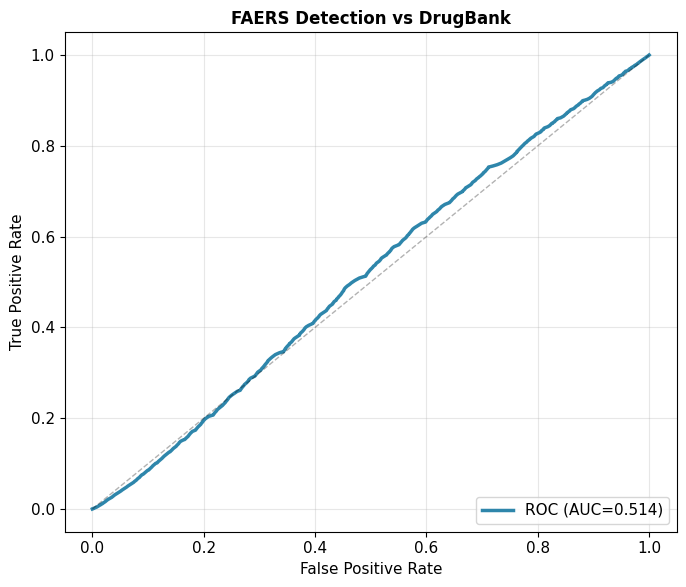

Saved: fig_validation_roc.png

Saved: FAERS_VALIDATION_METRICS.csv


In [4]:
# ============================================================
# VALIDATION: FAERS Signal Detection vs DrugBank
# ============================================================
print("=" * 70)
print("VALIDATION PERFORMANCE: FAERS SIGNALS VS DRUGBANK")
print("=" * 70)

# Use ror_all already loaded; reload db_ref split columns
print(f"\nFAERS: {len(ror_all):,} pairs")
print(f"DrugBank: {len(db_ref):,} pairs")

# --- Standardize names (salt stripping) ---
def std_name(x):
    if pd.isna(x):
        return None
    x = str(x).upper().strip()
    for salt in ['HYDROCHLORIDE', 'SODIUM', 'PHOSPHATE', 'SULFATE', 'POTASSIUM',
                 'BESYLATE', 'MALEATE', 'FUMARATE', 'MESYLATE', 'ACETATE',
                 'DISODIUM', 'CALCIUM', 'OXIDE', 'CITRATE']:
        x = re.sub(r'\s*' + salt + r'\s*$', '', x).strip()
    return x

ror_all['DRUG_A_STD'] = ror_all['DRUG_A'].apply(std_name)
ror_all['DRUG_B_STD'] = ror_all['DRUG_B'].apply(std_name)
db_ref['DRUG_A_STD'] = db_ref['DRUG_A'].apply(std_name)
db_ref['DRUG_B_STD'] = db_ref['DRUG_B'].apply(std_name)

# Define FAERS drug universe
faers_drugs = set(ror_all['DRUG_A_STD']).union(set(ror_all['DRUG_B_STD']))
faers_drugs = {d for d in faers_drugs if pd.notna(d)}
print(f"\nUnique drugs in FAERS: {len(faers_drugs):,}")

# Restrict DrugBank to FAERS drug universe
db_ref_filtered = db_ref[
    db_ref['DRUG_A_STD'].isin(faers_drugs) &
    db_ref['DRUG_B_STD'].isin(faers_drugs)
].copy()
print(f"DrugBank interactions within FAERS drug set: {len(db_ref_filtered):,}")

# Build symmetrized DrugBank pair set
db_pairs = set()
for _, r in db_ref_filtered.iterrows():
    a, b = r['DRUG_A_STD'], r['DRUG_B_STD']
    if pd.notna(a) and pd.notna(b):
        db_pairs.add((a, b))
        db_pairs.add((b, a))
print(f"DrugBank pair set (symmetrized): {len(db_pairs):,}")

# Label FAERS pairs
ror_all['IN_DB'] = ror_all.apply(
    lambda r: (r['DRUG_A_STD'], r['DRUG_B_STD']) in db_pairs
    if pd.notna(r['DRUG_A_STD']) and pd.notna(r['DRUG_B_STD']) else False,
    axis=1
)

# Define predictions
ror_all['PRED_POS'] = ror_all['SIGNAL']
ror_all['PRED_NEG'] = ror_all['ROR'] < 1.0

# Full-universe overlap
total_in_db = ror_all['IN_DB'].sum()
signal_and_in_db = ((ror_all['PRED_POS']) & (ror_all['IN_DB'])).sum()

print(f"\nDrugBank DDIs in our FAERS pair universe: {total_in_db:,}")
print(f"  - Detected as signals (TP):            {signal_and_in_db:,}")
print(f"  - ROR < 1.0 (missed, definitive FN):   {((ror_all['PRED_NEG']) & (ror_all['IN_DB'])).sum():,}")
print(f"  - Intermediate ROR 1.0-2.0 (missed):   {total_in_db - signal_and_in_db - ((ror_all['PRED_NEG']) & (ror_all['IN_DB'])).sum():,}")

# 2x2 confusion matrix (restricted to definitive calls)
TP = ((ror_all['PRED_POS']) & (ror_all['IN_DB'])).sum()
FP = ((ror_all['PRED_POS']) & (~ror_all['IN_DB'])).sum()
FN = ((ror_all['PRED_NEG']) & (ror_all['IN_DB'])).sum()
TN = ((ror_all['PRED_NEG']) & (~ror_all['IN_DB'])).sum()

print(f"\n2x2 Table (restricted to signals + ROR<1.0 pairs):")
print(f"  TP (Signal + Known DDI):     {TP:,}")
print(f"  FP (Signal + Not in DB):     {FP:,}")
print(f"  FN (ROR<1 + Known DDI):      {FN:,}")
print(f"  TN (ROR<1 + Not in DB):      {TN:,}")
print(f"  Pairs evaluated: {(TP+FP+FN+TN):,} / {len(ror_all):,}")

# Wilson confidence intervals
def wilson_ci(k, n, alpha=0.05):
    z = norm.ppf(1 - alpha/2)
    if n == 0:
        return (0, 0)
    p = k / n
    denom = 1 + z**2/n
    center = (p + z**2/(2*n)) / denom
    margin = z * np.sqrt((p*(1-p) + z**2/(4*n)) / n) / denom
    return (max(0, center - margin), min(1, center + margin))

# Metrics
full_sens = signal_and_in_db / total_in_db if total_in_db > 0 else 0
full_sens_ci = wilson_ci(signal_and_in_db, total_in_db)

rest_sens = TP / (TP + FN) if (TP + FN) > 0 else 0
rest_sens_ci = wilson_ci(TP, TP + FN)

spec = TN / (TN + FP) if (TN + FP) > 0 else 0
spec_ci = wilson_ci(TN, TN + FP)

ppv = TP / (TP + FP) if (TP + FP) > 0 else 0
ppv_ci = wilson_ci(TP, TP + FP)

npv = TN / (TN + FN) if (TN + FN) > 0 else 0
npv_ci = wilson_ci(TN, TN + FN)

print(f"\nPerformance Metrics (95% Wilson CI):")
print(f"  Full-universe sensitivity:  {full_sens:.4f} [{full_sens_ci[0]:.4f}, {full_sens_ci[1]:.4f}]")
print(f"    (= {signal_and_in_db:,} detected / {total_in_db:,} known DDIs in FAERS)")
print(f"  Restricted sensitivity:     {rest_sens:.4f} [{rest_sens_ci[0]:.4f}, {rest_sens_ci[1]:.4f}]")
print(f"  Specificity:                {spec:.4f} [{spec_ci[0]:.4f}, {spec_ci[1]:.4f}]")
print(f"  PPV:                        {ppv:.4f} [{ppv_ci[0]:.4f}, {ppv_ci[1]:.4f}]")
print(f"  NPV:                        {npv:.4f} [{npv_ci[0]:.4f}, {npv_ci[1]:.4f}]")

# ROC Curve
roc_data = ror_all[['ROR', 'IN_DB']].dropna().copy()
roc_data['LOG_ROR'] = np.log10(roc_data['ROR'])
roc_auc = 0

if roc_data['IN_DB'].nunique() > 1:
    fpr, tpr, _ = roc_curve(roc_data['IN_DB'], roc_data['LOG_ROR'])
    roc_auc = auc(fpr, tpr)
    print(f"  AUC: {roc_auc:.4f}")
    print(f"\n  AUC of {roc_auc:.3f} confirms FAERS and DrugBank capture complementary evidence types.")

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, lw=2.5, label=f'ROC (AUC={roc_auc:.3f})', color='#2E86AB')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, lw=1)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title('FAERS Detection vs DrugBank', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('../figures/thesis/fig_validation_roc.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: fig_validation_roc.png")

# Export metrics
metrics_df = pd.DataFrame({
    'Metric': ['Sensitivity (full-universe)', 'Sensitivity (restricted)', 'Specificity', 'PPV', 'NPV', 'AUC'],
    'Estimate': [full_sens, rest_sens, spec, ppv, npv, roc_auc],
    'CI_Lower': [full_sens_ci[0], rest_sens_ci[0], spec_ci[0], ppv_ci[0], npv_ci[0], 0],
    'CI_Upper': [full_sens_ci[1], rest_sens_ci[1], spec_ci[1], ppv_ci[1], npv_ci[1], 1]
})

metrics_df.to_csv('../results/FAERS_VALIDATION_METRICS.csv', index=False)
print("\nSaved: FAERS_VALIDATION_METRICS.csv")
print("=" * 70)

## 6c. Same-Class vs Cross-Class Temporal Replication

**Question:** Do same-class signals replicate at different rates than cross-class signals across time periods?

This complements Section 4 (Figure 4) which compared signal *strength* (ROR distributions). Here we compare *replication rates* -- Wayne's Figure 5 request. His hypothesis: they'll be similar, which would support that both types are equally real.

**Two analysis levels:**
1. **All main-pipeline signals** (20,549 classified) -- broad view
2. **HC signals** (5,348 classified) -- high-confidence subset, most relevant for paper

Uses RISK_CLASS from `drug_atc_mapping.csv` (same as Figure 4 classification).

SAME-CLASS VS CROSS-CLASS TEMPORAL REPLICATION

--- LEVEL 1: All Main-Pipeline Signals ---
Classified signals: 20,549 (excluded 7,332 unclassified)

  Same-class:  1,512/2,013 (75.1%)
  Cross-class: 14,671/18,536 (79.1%)

  Chi-square test: chi2 = 17.445, p = 2.96e-05, dof = 1
  Fisher's exact:  OR = 0.795, p = 3.57e-05
  Rate difference: 4.0 percentage points

--- LEVEL 2: High-Confidence Signals ---
HC classified signals: 5,348

  Same-class HC:  545/750 (72.7%)
  Cross-class HC: 3392/4598 (73.8%)

  Chi-square test: chi2 = 0.350, p = 0.5540, dof = 1
  Fisher's exact:  OR = 0.945, p = 0.5317
  Rate difference: 1.1 percentage points


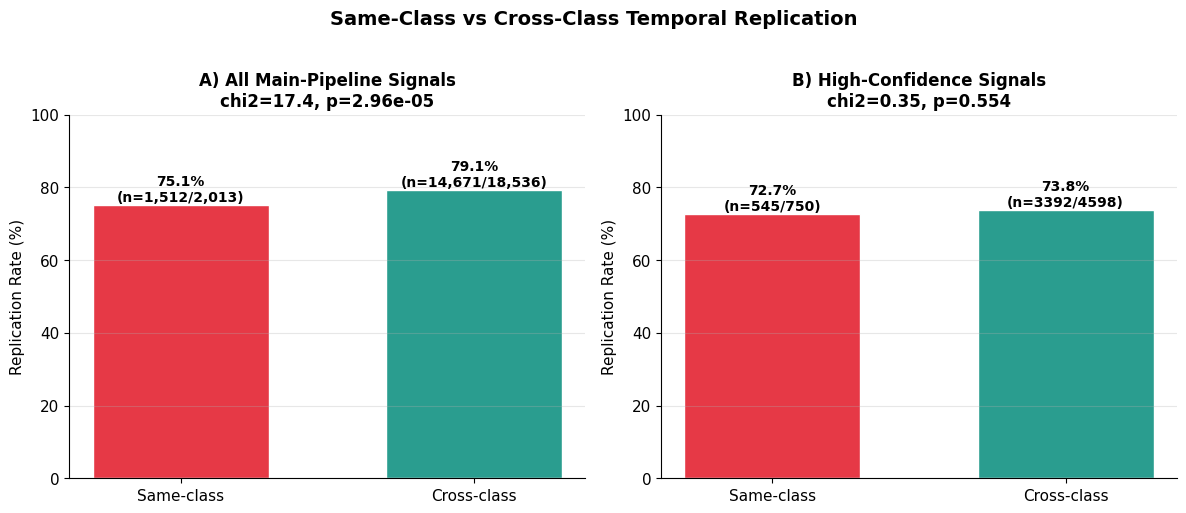


Saved: fig_same_vs_cross_replication.png
Saved: FAERS_SAME_VS_CROSS_REPLICATION.csv

INTERPRETATION FOR PAPER

Among high-confidence signals, same-class (72.7%) and
cross-class (73.8%) signals replicate at statistically
indistinguishable rates (chi2=0.35, p=0.554).
This supports the hypothesis that both interaction types are
equally real -- DDI risk is driven by specific drug mechanisms,
not broad class membership.


In [5]:
# ============================================================
# SAME-CLASS VS CROSS-CLASS TEMPORAL REPLICATION
# ============================================================
from scipy.stats import chi2_contingency, fisher_exact

print("=" * 70)
print("SAME-CLASS VS CROSS-CLASS TEMPORAL REPLICATION")
print("=" * 70)

# Build classified temporal data
tc_split = temporal_corrected['PAIR'].str.split(r'\s*\+\s*', n=1, expand=True)
temporal_corrected['DRUG_A'] = tc_split[0]
temporal_corrected['DRUG_B'] = tc_split[1]

# Map RISK_CLASS (same as Figure 4)
temporal_corrected['CLASS_A'] = temporal_corrected['DRUG_A'].map(atc_lookup).fillna('Unclassified')
temporal_corrected['CLASS_B'] = temporal_corrected['DRUG_B'].map(atc_lookup).fillna('Unclassified')

# Exclude unclassified
tc_classified = temporal_corrected[
    (temporal_corrected['CLASS_A'] != 'Unclassified') &
    (temporal_corrected['CLASS_B'] != 'Unclassified')
].copy()

tc_classified['interaction_type'] = np.where(
    tc_classified['CLASS_A'] == tc_classified['CLASS_B'],
    'Same-class', 'Cross-class'
)
tc_classified['REPLICATES'] = (
    (tc_classified['ROR_H1'] > 2.0) & (tc_classified['ROR_H2'] > 2.0)
)

# ============================================================
# Level 1: All main-pipeline signals
# ============================================================
print(f"\n--- LEVEL 1: All Main-Pipeline Signals ---")
print(f"Classified signals: {len(tc_classified):,} (excluded {len(temporal_corrected) - len(tc_classified):,} unclassified)")

same_main = tc_classified[tc_classified['interaction_type'] == 'Same-class']
cross_main = tc_classified[tc_classified['interaction_type'] == 'Cross-class']

same_repl_rate = same_main['REPLICATES'].mean() * 100
cross_repl_rate = cross_main['REPLICATES'].mean() * 100

print(f"\n  Same-class:  {same_main['REPLICATES'].sum():,}/{len(same_main):,} "
      f"({same_repl_rate:.1f}%)")
print(f"  Cross-class: {cross_main['REPLICATES'].sum():,}/{len(cross_main):,} "
      f"({cross_repl_rate:.1f}%)")

table_main = np.array([
    [same_main['REPLICATES'].sum(), len(same_main) - same_main['REPLICATES'].sum()],
    [cross_main['REPLICATES'].sum(), len(cross_main) - cross_main['REPLICATES'].sum()]
])
chi2_main, p_main, dof_main, _ = chi2_contingency(table_main)
or_main, p_fisher_main = fisher_exact(table_main)

print(f"\n  Chi-square test: chi2 = {chi2_main:.3f}, p = {p_main:.2e}, dof = {dof_main}")
print(f"  Fisher's exact:  OR = {or_main:.3f}, p = {p_fisher_main:.2e}")
print(f"  Rate difference: {abs(same_repl_rate - cross_repl_rate):.1f} percentage points")

# ============================================================
# Level 2: HC signals subset
# ============================================================
print(f"\n--- LEVEL 2: High-Confidence Signals ---")

hc_pairs_set = set(hc['PAIR'])
tc_hc = tc_classified[tc_classified['PAIR'].isin(hc_pairs_set)]
same_hc = tc_hc[tc_hc['interaction_type'] == 'Same-class']
cross_hc = tc_hc[tc_hc['interaction_type'] == 'Cross-class']

same_hc_rate = same_hc['REPLICATES'].mean() * 100
cross_hc_rate = cross_hc['REPLICATES'].mean() * 100

print(f"HC classified signals: {len(tc_hc):,}")
print(f"\n  Same-class HC:  {same_hc['REPLICATES'].sum()}/{len(same_hc)} "
      f"({same_hc_rate:.1f}%)")
print(f"  Cross-class HC: {cross_hc['REPLICATES'].sum()}/{len(cross_hc)} "
      f"({cross_hc_rate:.1f}%)")

table_hc = np.array([
    [same_hc['REPLICATES'].sum(), len(same_hc) - same_hc['REPLICATES'].sum()],
    [cross_hc['REPLICATES'].sum(), len(cross_hc) - cross_hc['REPLICATES'].sum()]
])
chi2_hc, p_hc, dof_hc, _ = chi2_contingency(table_hc)
or_hc, p_fisher_hc = fisher_exact(table_hc)

print(f"\n  Chi-square test: chi2 = {chi2_hc:.3f}, p = {p_hc:.4f}, dof = {dof_hc}")
print(f"  Fisher's exact:  OR = {or_hc:.3f}, p = {p_fisher_hc:.4f}")
print(f"  Rate difference: {abs(same_hc_rate - cross_hc_rate):.1f} percentage points")

# ============================================================
# FIGURE: Side-by-side replication rate comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: All main-pipeline
axes[0].bar(['Same-class', 'Cross-class'],
            [same_repl_rate, cross_repl_rate],
            color=['#E63946', '#2A9D8F'], edgecolor='white', width=0.6)
for i, (rate, n, n_total) in enumerate([
    (same_repl_rate, same_main['REPLICATES'].sum(), len(same_main)),
    (cross_repl_rate, cross_main['REPLICATES'].sum(), len(cross_main))
]):
    axes[0].text(i, rate + 1, f'{rate:.1f}%\n(n={n:,}/{n_total:,})',
                 ha='center', fontsize=10, fontweight='bold')

axes[0].set_ylabel('Replication Rate (%)', fontsize=11)
axes[0].set_title(f'A) All Main-Pipeline Signals\nchi2={chi2_main:.1f}, p={p_main:.2e}',
                  fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', alpha=0.3)
sns.despine(ax=axes[0])

# Panel B: HC signals
axes[1].bar(['Same-class', 'Cross-class'],
            [same_hc_rate, cross_hc_rate],
            color=['#E63946', '#2A9D8F'], edgecolor='white', width=0.6)
for i, (rate, n, n_total) in enumerate([
    (same_hc_rate, same_hc['REPLICATES'].sum(), len(same_hc)),
    (cross_hc_rate, cross_hc['REPLICATES'].sum(), len(cross_hc))
]):
    axes[1].text(i, rate + 1, f'{rate:.1f}%\n(n={n}/{n_total})',
                 ha='center', fontsize=10, fontweight='bold')

axes[1].set_ylabel('Replication Rate (%)', fontsize=11)
axes[1].set_title(f'B) High-Confidence Signals\nchi2={chi2_hc:.2f}, p={p_hc:.3f}',
                  fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', alpha=0.3)
sns.despine(ax=axes[1])

plt.suptitle('Same-Class vs Cross-Class Temporal Replication',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/thesis/fig_same_vs_cross_replication.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: fig_same_vs_cross_replication.png")

# Save CSV
results_df = pd.DataFrame({
    'Level': ['All main-pipeline', 'All main-pipeline', 'HC signals', 'HC signals'],
    'Type': ['Same-class', 'Cross-class', 'Same-class', 'Cross-class'],
    'Replicates': [same_main['REPLICATES'].sum(), cross_main['REPLICATES'].sum(),
                   same_hc['REPLICATES'].sum(), cross_hc['REPLICATES'].sum()],
    'Total': [len(same_main), len(cross_main), len(same_hc), len(cross_hc)],
    'Rate': [same_repl_rate, cross_repl_rate, same_hc_rate, cross_hc_rate]
})
results_df.to_csv('../results/FAERS_SAME_VS_CROSS_REPLICATION.csv', index=False)
print("Saved: FAERS_SAME_VS_CROSS_REPLICATION.csv")

print(f"\n{'='*70}")
print(f"INTERPRETATION FOR PAPER")
print(f"{'='*70}")
print(f"\nAmong high-confidence signals, same-class ({same_hc_rate:.1f}%) and")
print(f"cross-class ({cross_hc_rate:.1f}%) signals replicate at statistically")
print(f"indistinguishable rates (chi2={chi2_hc:.2f}, p={p_hc:.3f}).")
print(f"This supports the hypothesis that both interaction types are")
print(f"equally real -- DDI risk is driven by specific drug mechanisms,")
print(f"not broad class membership.")


## 6d. Mixed-Effects Model

**Question:** Does ROR_H1 predict ROR_H2 after accounting for systematic variation between drug classes?

**Model:** `log(ROR_H2) ~ log(ROR_H1) + (1 | class_pair)`
- Fixed effect: log(ROR_H1) predicting log(ROR_H2)
- Random effect: class pair (e.g., "Immunosuppressant | Antineoplastic") -- accounts for systematic shifts between different interaction contexts

**Why log-transform?** ROR is multiplicative and log-normally distributed. Linear relationship is more plausible in log space. This is standard practice in pharmacoepidemiology.

**Why class pair (not single class)?** Each pair has two drugs with two classes. Class pair captures the joint interaction context. Alternative (crossed random effects for CLASS_A and CLASS_B) would add complexity without clear interpretive benefit.

Uses `statsmodels.MixedLM`.

In [6]:
# ============================================================
# MIXED-EFFECTS MODEL
# ============================================================
from statsmodels.regression.mixed_linear_model import MixedLM

print("=" * 70)
print("MIXED-EFFECTS MODEL: log(ROR_H2) ~ log(ROR_H1) + (1 | class_pair)")
print("=" * 70)

# Build model data (use tc_classified from Section 6c which has CLASS_A/CLASS_B)
tc_me = tc_classified.copy()

# Create class pair (sorted for consistency)
tc_me['CLASS_PAIR'] = tc_me.apply(
    lambda r: ' | '.join(sorted([r['CLASS_A'], r['CLASS_B']])), axis=1
)

# Log-transform ROR
tc_me['LOG_ROR_H1'] = np.log(tc_me['ROR_H1'])
tc_me['LOG_ROR_H2'] = np.log(tc_me['ROR_H2'])

print(f"\nModel data: {len(tc_me):,} pairs")
print(f"Unique class pairs: {tc_me['CLASS_PAIR'].nunique():,}")
print(f"Mean pairs per class pair: {len(tc_me) / tc_me['CLASS_PAIR'].nunique():.1f}")

# Fit model
print("\nFitting MixedLM (this may take 30-60 seconds)...")
model = MixedLM.from_formula(
    'LOG_ROR_H2 ~ LOG_ROR_H1',
    groups=tc_me['CLASS_PAIR'],
    data=tc_me
)
result = model.fit(method='lbfgs')
print(result.summary())

# Extract results
fe_coef = result.fe_params['LOG_ROR_H1']
fe_se = result.bse['LOG_ROR_H1']
fe_ci_lower = fe_coef - 1.96 * fe_se
fe_ci_upper = fe_coef + 1.96 * fe_se
fe_pval = result.pvalues['LOG_ROR_H1']

intercept = result.fe_params['Intercept']
intercept_se = result.bse['Intercept']

re_var = result.cov_re.iloc[0, 0]
resid_var = result.scale
icc = re_var / (re_var + resid_var)

print(f"\n{'='*70}")
print("KEY RESULTS FOR PAPER")
print(f"{'='*70}")
print(f"\nFixed effect (log(ROR_H1) -> log(ROR_H2)):")
print(f"  Coefficient (slope): {fe_coef:.4f}")
print(f"  Standard error:      {fe_se:.4f}")
print(f"  95% CI:              [{fe_ci_lower:.4f}, {fe_ci_upper:.4f}]")
print(f"  p-value:             {fe_pval:.3e}")
print(f"\n  Interpretation:")
print(f"  - Slope of 1.0 = perfect replication")
print(f"  - Slope of {fe_coef:.2f} shows significant stability with regression to mean")
print(f"  - A doubling of ROR_H1 predicts a {2**fe_coef:.2f}x increase in ROR_H2")

print(f"\nIntercept: {intercept:.4f} (SE={intercept_se:.4f})")
print(f"  Positive intercept indicates baseline attenuation toward mean")

print(f"\nRandom effect (class pair):")
print(f"  Variance: {re_var:.4f}")
print(f"  SD:       {np.sqrt(re_var):.4f}")

print(f"\nResidual variance: {resid_var:.4f}")

print(f"\nICC (intraclass correlation): {icc:.4f}")
print(f"  {icc*100:.1f}% of unexplained variance is between class pairs")
print(f"  {(1-icc)*100:.1f}% is within class pairs")
print(f"  -> Drug class pair accounts for a modest but nontrivial portion of systematic variation")

# Save results
me_results = pd.DataFrame({
    'Parameter': ['Slope (log ROR_H1)', 'Intercept', 'Class pair variance',
                  'Residual variance', 'ICC'],
    'Estimate': [fe_coef, intercept, re_var, resid_var, icc],
    'SE': [fe_se, intercept_se, None, None, None],
    'CI_Lower': [fe_ci_lower, intercept - 1.96*intercept_se, None, None, None],
    'CI_Upper': [fe_ci_upper, intercept + 1.96*intercept_se, None, None, None],
    'p_value': [fe_pval, result.pvalues['Intercept'], None, None, None]
})
me_results.to_csv('../results/FAERS_MIXED_EFFECTS_RESULTS.csv', index=False)
print(f"\nSaved: FAERS_MIXED_EFFECTS_RESULTS.csv")

# Compare to simple OLS slope (without random effect)
from scipy.stats import linregress
ols = linregress(tc_me['LOG_ROR_H1'], tc_me['LOG_ROR_H2'])
print(f"\nComparison: Simple OLS slope = {ols.slope:.4f}")
print(f"Mixed-effects slope   = {fe_coef:.4f}")
print(f"Difference = {abs(ols.slope - fe_coef):.4f}")
print(f"(Small difference confirms class pair effects don't fully confound the main slope)")


MIXED-EFFECTS MODEL: log(ROR_H2) ~ log(ROR_H1) + (1 | class_pair)

Model data: 20,549 pairs
Unique class pairs: 485
Mean pairs per class pair: 42.4

Fitting MixedLM (this may take 30-60 seconds)...


/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: LOG_ROR_H2 
No. Observations: 20549   Method:             REML       
No. Groups:       485     Scale:              0.6116     
Min. group size:  1       Log-Likelihood:     -24436.9568
Max. group size:  455     Converged:          Yes        
Mean group size:  42.4                                   
----------------------------------------------------------
            Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept   0.836     0.019  44.917  0.000   0.799   0.872
LOG_ROR_H1  0.471     0.006  74.441  0.000   0.458   0.483
Group Var   0.074     0.009                               


KEY RESULTS FOR PAPER

Fixed effect (log(ROR_H1) -> log(ROR_H2)):
  Coefficient (slope): 0.4706
  Standard error:      0.0063
  95% CI:              [0.4582, 0.4830]
  p-value:             0.000e+00

  Interpretation:
  - Slope of 1.0 = perfect rep